# 02 - Patrones de vulnerabilidades

## Introducción
Este notebook analiza patrones transversales de vulnerabilidades y hallazgos CodeQL.
Explora primero los datos raw del Miner para obtener insights detallados (CVSS, EPSS, fix versions),
luego valida contra el consolidado `analysis.json`.

## Pregunta que responde
**¿Qué riesgos se repiten, en qué componentes se concentran y cómo priorizar mitigaciones de forma defendible?**

### Cómo interpretar esta sección
- **FASE 1**: EDA avanzado sobre datos raw (CVSS, EPSS, risk, fix gap, locations).
- **FASE 2**: Análisis del consolidado `analysis.json` (severidad, CWE, correlaciones).
- **CI/CD (Bonus)**: hallazgos operativos de menor prioridad, análisis complementario.
- **Validación cruzada**: Comparación de patrones entre raw y consolidado.

### Por qué importa en ciberseguridad
Los patrones repetidos suelen indicar deuda sistémica, no incidentes aislados. Identificarlos mejora priorización y eficiencia de remediación.


## FASE 1 — Análisis avanzado sobre datos raw

Se leen directamente los archivos raw del Miner para extraer campos que no están en el consolidado:
CVSS scores, EPSS, fix versions, locations, y descripciones completas.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'results' / 'analysis.json').exists():
            return candidate
    return Path.cwd()


root = find_project_root()
vuln_dir = root / 'data' / 'results' / 'vulns'
reports_dir = root / 'data' / 'reports'
analysis_path = root / 'data' / 'results' / 'analysis.json'

# ── Carga RAW: Grype completo ──
grype_rows = []
for p in sorted(vuln_dir.glob('*_vuln.json')):
    data = json.loads(p.read_text(encoding='utf-8'))
    repo = p.name.replace('_vuln.json', '')
    for match in data.get('matches', []):
        vuln = match.get('vulnerability', {})
        artifact = match.get('artifact', {})
        cvss_list = vuln.get('cvss', [])
        cvss_score = None
        cvss_vector = None
        if isinstance(cvss_list, list) and cvss_list:
            first = cvss_list[0]
            if isinstance(first, dict):
                metrics = first.get('metrics', {})
                if isinstance(metrics, dict):
                    cvss_score = metrics.get('baseScore')
                    cvss_vector = metrics.get('vectorString')
        epss_list = vuln.get('epss', [])
        epss = None
        epss_percentile = None
        if isinstance(epss_list, list) and epss_list:
            first = epss_list[0]
            if isinstance(first, dict):
                epss = first.get('epss')
                epss_percentile = first.get('percentile')
        cwe_list = vuln.get('cwes', [])
        cwe = None
        if isinstance(cwe_list, list) and cwe_list:
            first = cwe_list[0]
            if isinstance(first, dict):
                cwe = first.get('cwe')
        fix = vuln.get('fix', {})
        locations = artifact.get('locations', [])
        location = None
        if isinstance(locations, list) and locations:
            first_loc = locations[0]
            if isinstance(first_loc, dict):
                location = first_loc.get('path')
        grype_rows.append({
            'repo': repo,
            'id': vuln.get('id', ''),
            'severity': vuln.get('severity', 'Unknown'),
            'description': vuln.get('description', ''),
            'cvss_score': cvss_score,
            'cvss_vector': cvss_vector,
            'epss': epss,
            'epss_percentile': epss_percentile,
            'cwe': cwe or 'Unknown',
            'risk': vuln.get('risk'),
            'artifact': artifact.get('name', ''),
            'artifact_version': artifact.get('version', ''),
            'artifact_type': artifact.get('type', 'unknown'),
            'artifact_language': artifact.get('language', '') or 'unknown',
            'location': location,
            'fix_state': fix.get('state', 'unknown'),
            'fix_available': fix.get('state', '').lower() == 'fixed' or bool(fix.get('versions')),
            'fix_versions': fix.get('versions', []),
            'fix_version': fix.get('versions', [None])[0] if fix.get('versions') else None,
        })
df_grype = pd.DataFrame(grype_rows)
if df_grype.empty:
    df_grype = pd.DataFrame(columns=['repo','id','severity','description','cvss_score','cvss_vector','epss','epss_percentile','cwe','risk','artifact','artifact_version','artifact_type','artifact_language','location','fix_state','fix_available','fix_versions','fix_version'])

print(f"Grype raw: {len(df_grype)} vulnerabilidades en {df_grype['repo'].nunique()} repos")
if not df_grype.empty:
    display(df_grype.head())


Grype raw: 280 vulnerabilidades en 42 repos


,repo,id,severity,description,cvss_score,cvss_vector,epss,epss_percentile,cwe,risk,artifact,artifact_version,artifact_type,artifact_language,location,fix_state,fix_available,fix_versions,fix_version
0,agent-auth-payments,GHSA-w5hq-g745-h8pq,Medium,uuid: Missing buffer bounds check in v3/v5/v6 ...,6.3,None,0.00055,0.17057,CWE-787,0.031075,uuid,11.1.0,npm,javascript,/pnpm-lock.yaml,fixed,True,[11.1.1],11.1.1
1,agent-auth-payments,GHSA-w5hq-g745-h8pq,Medium,uuid: Missing buffer bounds check in v3/v5/v6 ...,6.3,None,0.00055,0.17057,CWE-787,0.031075,uuid,13.0.0,npm,javascript,/pnpm-lock.yaml,fixed,True,[13.0.1],13.0.1
2,agent-auth-payments,GHSA-fw9q-39r9-c252,Medium,LangSmith Client SDKs has Prototype Pollution ...,5.6,None,0.00052,0.16113,CWE-1321,0.027560,langsmith,0.5.6,npm,javascript,/pnpm-lock.yaml,fixed,True,[0.5.18],0.5.18
3,agent-auth-payments,GHSA-rr7j-v2q5-chgv,Medium,LangSmith SDK: Streaming token events bypass o...,5.3,None,0.00036,0.10572,CWE-200,0.018540,langsmith,0.5.6,npm,javascript,/pnpm-lock.yaml,fixed,True,[0.5.19],0.5.19
4,agent-auth-payments,GHSA-qx2v-qp2m-jg93,Medium,PostCSS has XSS via Unescaped </style> in its ...,6.1,None,0.00031,0.08954,CWE-79,0.017205,postcss,8.4.31,npm,javascript,/pnpm-lock.yaml,fixed,True,[8.5.10],8.5.10


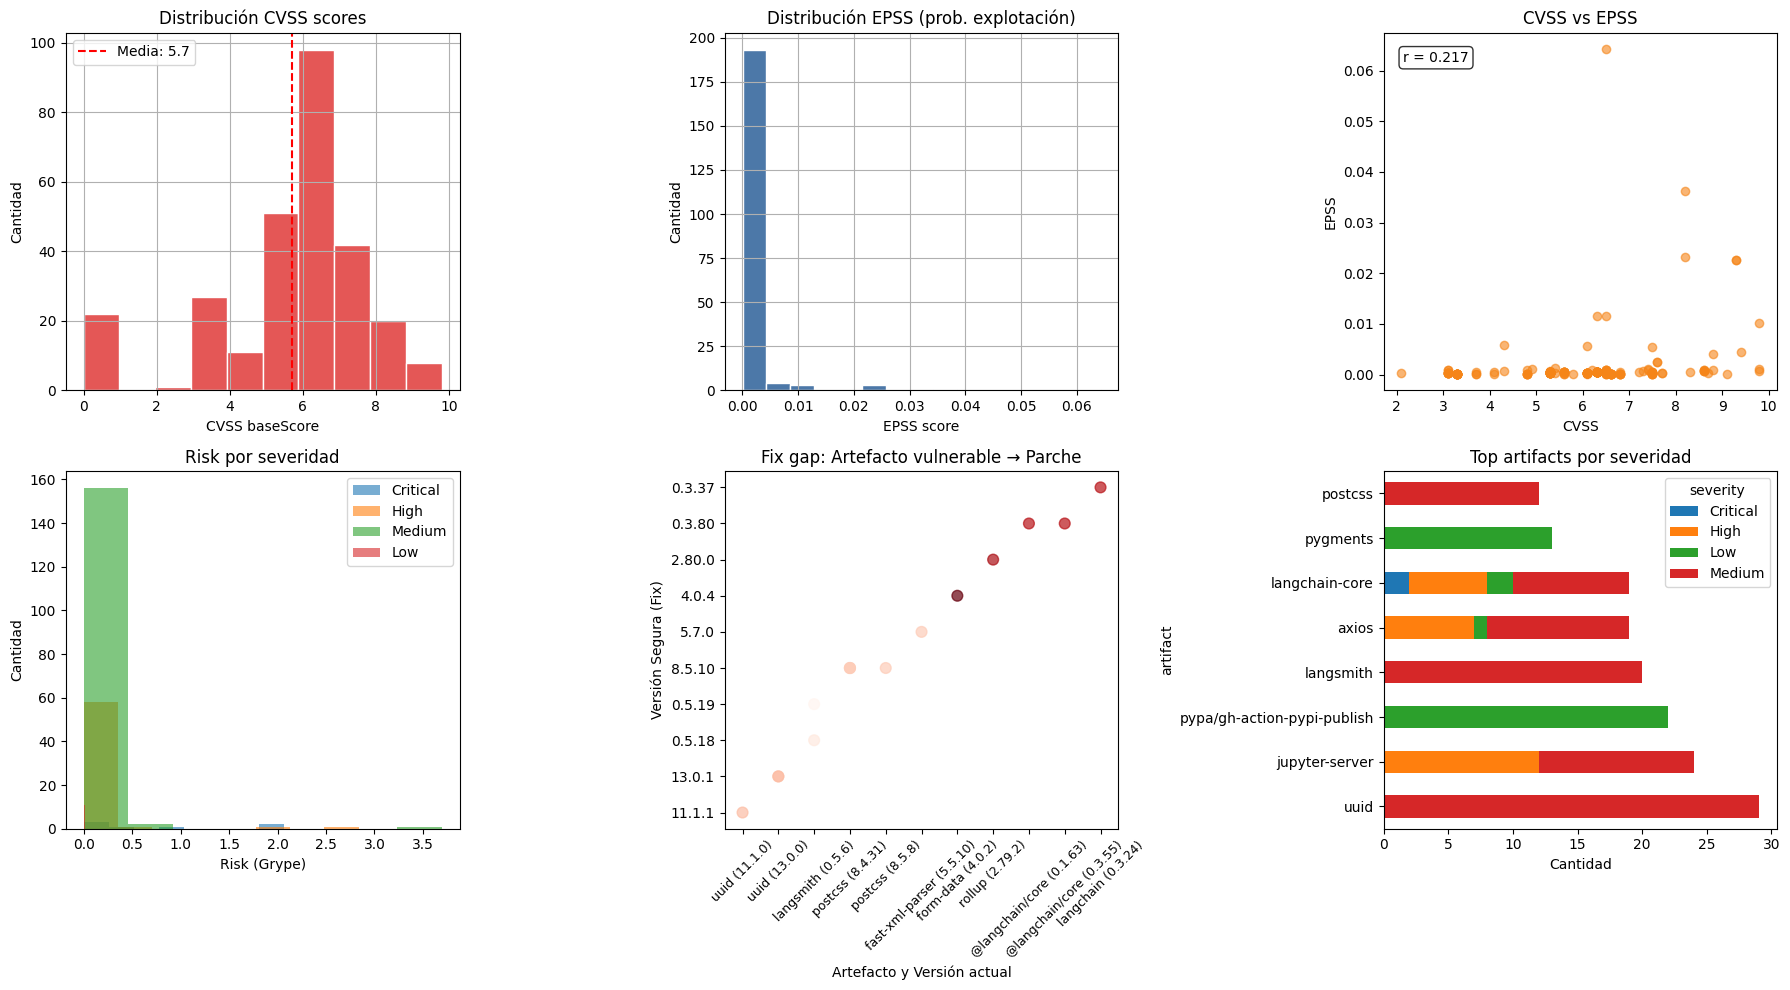


Resumen EDA avanzado:
  CVSS promedio: 5.71
  EPSS promedio: 0.001500
  Risk promedio: 0.075594
  Fix disponible: 269/280 (96.1%)
  Con fix_version: 269/280
  Con location: 280/280


In [2]:
# ── EDA avanzado: CVSS, EPSS, risk, fix gap ──
if not df_grype.empty:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1. Distribución CVSS
    if df_grype['cvss_score'].notna().any():
        df_grype['cvss_score'].hist(bins=10, ax=axes[0, 0], color='#E45756', edgecolor='white')
        axes[0, 0].axvline(df_grype['cvss_score'].mean(), color='red', linestyle='--', label=f"Media: {df_grype['cvss_score'].mean():.1f}")
        axes[0, 0].set_title('Distribución CVSS scores')
        axes[0, 0].set_xlabel('CVSS baseScore')
        axes[0, 0].legend()
    else:
        axes[0, 0].text(0.5, 0.5, 'Sin datos CVSS', ha='center', va='center')
        axes[0, 0].set_title('Distribución CVSS scores')

    # 2. Distribución EPSS
    if df_grype['epss'].notna().any():
        df_grype['epss'].hist(bins=15, ax=axes[0, 1], color='#4C78A8', edgecolor='white')
        axes[0, 1].set_title('Distribución EPSS (prob. explotación)')
        axes[0, 1].set_xlabel('EPSS score')
    else:
        axes[0, 1].text(0.5, 0.5, 'Sin datos EPSS', ha='center', va='center')
        axes[0, 1].set_title('Distribución EPSS (prob. explotación)')

    # 3. CVSS vs EPSS scatter
    valid = df_grype[df_grype['cvss_score'].notna() & df_grype['epss'].notna()]
    if len(valid) >= 2:
        axes[0, 2].scatter(valid['cvss_score'], valid['epss'], alpha=0.6, color='#F58518')
        axes[0, 2].set_title('CVSS vs EPSS')
        axes[0, 2].set_xlabel('CVSS')
        axes[0, 2].set_ylabel('EPSS')
        corr = valid['cvss_score'].corr(valid['epss'])
        axes[0, 2].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[0, 2].transAxes,
                       fontsize=10, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        axes[0, 2].text(0.5, 0.5, 'Datos insuficientes', ha='center', va='center')
        axes[0, 2].set_title('CVSS vs EPSS')

    # 4. Risk distribution por severidad
    if df_grype['risk'].notna().any():
        for sev in ['Critical', 'High', 'Medium', 'Low']:
            sub = df_grype[df_grype['severity'] == sev]['risk']
            if not sub.empty:
                axes[1, 0].hist(sub, bins=8, alpha=0.6, label=sev)
        axes[1, 0].set_title('Risk por severidad')
        axes[1, 0].set_xlabel('Risk (Grype)')
        axes[1, 0].legend()
    else:
        axes[1, 0].text(0.5, 0.5, 'Sin datos risk', ha='center', va='center')
        axes[1, 0].set_title('Risk por severidad')

    # 5. Fix gap: versiones vulnerables vs fix
    # Usamos .copy() para evitar advertencias de pandas y filtramos datos válidos
    fix_df = df_grype[df_grype['fix_version'].notna() & (df_grype['artifact_version'] != '')].copy().head(15)

    if not fix_df.empty:
        # SOLUCIÓN 1: Combinar nombre + versión, pero truncando las versiones que sean hashes gigantes
        version_str = fix_df['artifact_version'].astype(str)
        version_corta = version_str.apply(lambda x: x[:12] + '...' if len(x) > 15 else x)
        fix_df['artifact_label'] = fix_df['artifact'] + " (" + version_corta + ")"
        # SOLUCIÓN 2: Rellenar con 0 los CVSS vacíos para evitar que matplotlib se rompa
        colores = fix_df['cvss_score'].fillna(0)
    
        axes[1, 1].scatter(fix_df['artifact_label'], fix_df['fix_version'].astype(str),
                        c=colores, cmap='Reds', s=60, alpha=0.7)
    
        axes[1, 1].set_title('Fix gap: Artefacto vulnerable → Parche')
        axes[1, 1].set_xlabel('Artefacto y Versión actual')
        axes[1, 1].set_ylabel('Versión Segura (Fix)')
    
        # Ajustamos el texto para que las etiquetas largas no se corten
        axes[1, 1].tick_params(axis='x', rotation=45, labelsize=9)
    else:
        axes[1, 1].text(0.5, 0.5, 'Sin datos de fix', ha='center', va='center')
        axes[1, 1].set_title('Fix gap: Artefacto vulnerable → Parche')

    # 6. Top artifacts por severidad
    top_art_sev = df_grype.groupby(['artifact', 'severity']).size().unstack(fill_value=0)
    top_art_sev = top_art_sev.loc[top_art_sev.sum(axis=1).nlargest(8).index]
    top_art_sev.plot(kind='barh', stacked=True, ax=axes[1, 2])
    axes[1, 2].set_title('Top artifacts por severidad')
    axes[1, 2].set_xlabel('Cantidad')

    for ax in axes.ravel():
        ax.set_ylabel(ax.get_ylabel() or 'Cantidad')
    plt.tight_layout()
    plt.show()

    print(f"\nResumen EDA avanzado:")
    print(f"  CVSS promedio: {df_grype['cvss_score'].mean():.2f}" if df_grype['cvss_score'].notna().any() else "  Sin datos CVSS.")
    print(f"  EPSS promedio: {df_grype['epss'].mean():.6f}" if df_grype['epss'].notna().any() else "  Sin datos EPSS.")
    print(f"  Risk promedio: {df_grype['risk'].mean():.6f}" if df_grype['risk'].notna().any() else "  Sin datos risk.")
    print(f"  Fix disponible: {df_grype['fix_available'].sum()}/{len(df_grype)} ({df_grype['fix_available'].mean()*100:.1f}%)")
    print(f"  Con fix_version: {df_grype['fix_version'].notna().sum()}/{len(df_grype)}")
    print(f"  Con location: {df_grype['location'].notna().sum()}/{len(df_grype)}")
else:
    print('Sin datos Grype raw.')


## FASE 2 — Análisis del consolidado (analysis.json)


In [3]:
if not analysis_path.exists():
    raise FileNotFoundError(f'No se encontró analysis.json en: {analysis_path}')

analysis = json.loads(analysis_path.read_text(encoding='utf-8'))

vuln_rows = []
repo_rows = []
codeql_rows = []

for repo in analysis.get('repositories', []) or []:
    repo_name = repo.get('name', 'unknown')
    repo_rows.append({
        'repo': repo_name,
        'components': repo.get('sbom', {}).get('total_components', 0),
        'vulnerabilities': repo.get('vulnerabilities', {}).get('total', 0),
    })

    for item in repo.get('vulnerabilities', {}).get('items', []) or []:
        vuln_rows.append({
            'repo': repo_name,
            'id': item.get('id', 'unknown'),
            'severity': item.get('severity', 'Unknown') or 'Unknown',
            'artifact': item.get('artifact', 'unknown') or 'unknown',
            'artifact_type': item.get('artifact_type', 'unknown') or 'unknown',
            'cwe': item.get('cwe', 'Unknown') or 'Unknown',
            'fix_available': bool(item.get('fix_available', False)),
        })

    for issue in repo.get('codeql', {}).get('items', []) or []:
        codeql_rows.append({
            'repo': repo_name,
            'rule_id': issue.get('rule_id', 'unknown') or 'unknown',
            'level': issue.get('level', 'unknown') or 'unknown',
        })

df_repo = pd.DataFrame(repo_rows)
df_vulns = pd.DataFrame(vuln_rows)
df_codeql = pd.DataFrame(codeql_rows)

if df_repo.empty:
    df_repo = pd.DataFrame(columns=['repo', 'components', 'vulnerabilities'])
if df_vulns.empty:
    df_vulns = pd.DataFrame(columns=['repo','id','severity','artifact','artifact_type','cwe','fix_available'])
if df_codeql.empty:
    df_codeql = pd.DataFrame(columns=['repo','rule_id','level'])

display(df_vulns.head())


,repo,id,severity,artifact,artifact_type,cwe,fix_available
0,agent-auth-payments,GHSA-w5hq-g745-h8pq,Medium,uuid,npm,CWE-787,True
1,agent-auth-payments,GHSA-w5hq-g745-h8pq,Medium,uuid,npm,CWE-787,True
2,agent-auth-payments,GHSA-fw9q-39r9-c252,Medium,langsmith,npm,CWE-1321,True
3,agent-auth-payments,GHSA-rr7j-v2q5-chgv,Medium,langsmith,npm,CWE-200,True
4,agent-auth-payments,GHSA-qx2v-qp2m-jg93,Medium,postcss,npm,CWE-79,True


In [4]:
severity_order = ['Critical', 'High', 'Medium', 'Low', 'Unknown']
severity_counts = df_vulns['severity'].value_counts().reindex(severity_order, fill_value=0)
top_artifacts = df_vulns['artifact'].value_counts().head(10)
top_cwe = df_vulns['cwe'].value_counts().head(10)
fix_counts = df_vulns['fix_available'].map({True: 'Fix disponible', False: 'Sin fix'}).value_counts()
by_type = df_vulns['artifact_type'].value_counts().head(10)

display(severity_counts.to_frame('count'))
display(top_artifacts.to_frame('count'))
display(top_cwe.to_frame('count'))
display(fix_counts.to_frame('count'))
display(by_type.to_frame('count'))

,count
severity,
Critical,7
High,61
Medium,159
Low,53
Unknown,0


,count
artifact,
uuid,29
jupyter-server,24
pypa/gh-action-pypi-publish,22
langsmith,20
axios,19
langchain-core,19
pygments,13
postcss,12
brace-expansion,9


,count
cwe,
Unknown,51
CWE-787,29
CWE-400,22
CWE-918,21
CWE-22,17
CWE-1321,15
CWE-200,14
CWE-79,13
CWE-1336,11


,count
fix_available,
Fix disponible,269
Sin fix,11


,count
artifact_type,
npm,146
python,107
github-action,26
go-module,1


## Validación cruzada: patrones RAW vs consolidado


In [5]:
if not df_grype.empty and not df_vulns.empty:
    raw_sev = df_grype['severity'].value_counts().reindex(severity_order, fill_value=0)
    cons_sev = df_vulns['severity'].value_counts().reindex(severity_order, fill_value=0)
    sev_comparison = pd.DataFrame({'raw': raw_sev, 'consolidado': cons_sev})
    sev_comparison['match'] = sev_comparison['raw'] == sev_comparison['consolidado']
    display(sev_comparison)
    print(f"\nSeveridad: {'✓ Coincide' if sev_comparison['match'].all() else '✗ Hay discrepancias'}")

    raw_by_type = df_grype['artifact_type'].value_counts()
    cons_by_type = df_vulns['artifact_type'].value_counts()
    type_comparison = pd.DataFrame({'raw': raw_by_type, 'consolidado': cons_by_type}).fillna(0)
    type_comparison['match'] = type_comparison['raw'] == type_comparison['consolidado']
    display(type_comparison)
    print(f"\nArtifact type: {'✓ Coincide' if type_comparison['match'].all() else '✗ Hay discrepancias'}")
else:
    print('Datos insuficientes para validación cruzada.')


,raw,consolidado,match
severity,,,
Critical,7,7,True
High,61,61,True
Medium,159,159,True
Low,53,53,True
Unknown,0,0,True



Severidad: ✓ Coincide


,raw,consolidado,match
artifact_type,,,
npm,146,146,True
python,107,107,True
github-action,26,26,True
go-module,1,1,True



Artifact type: ✓ Coincide


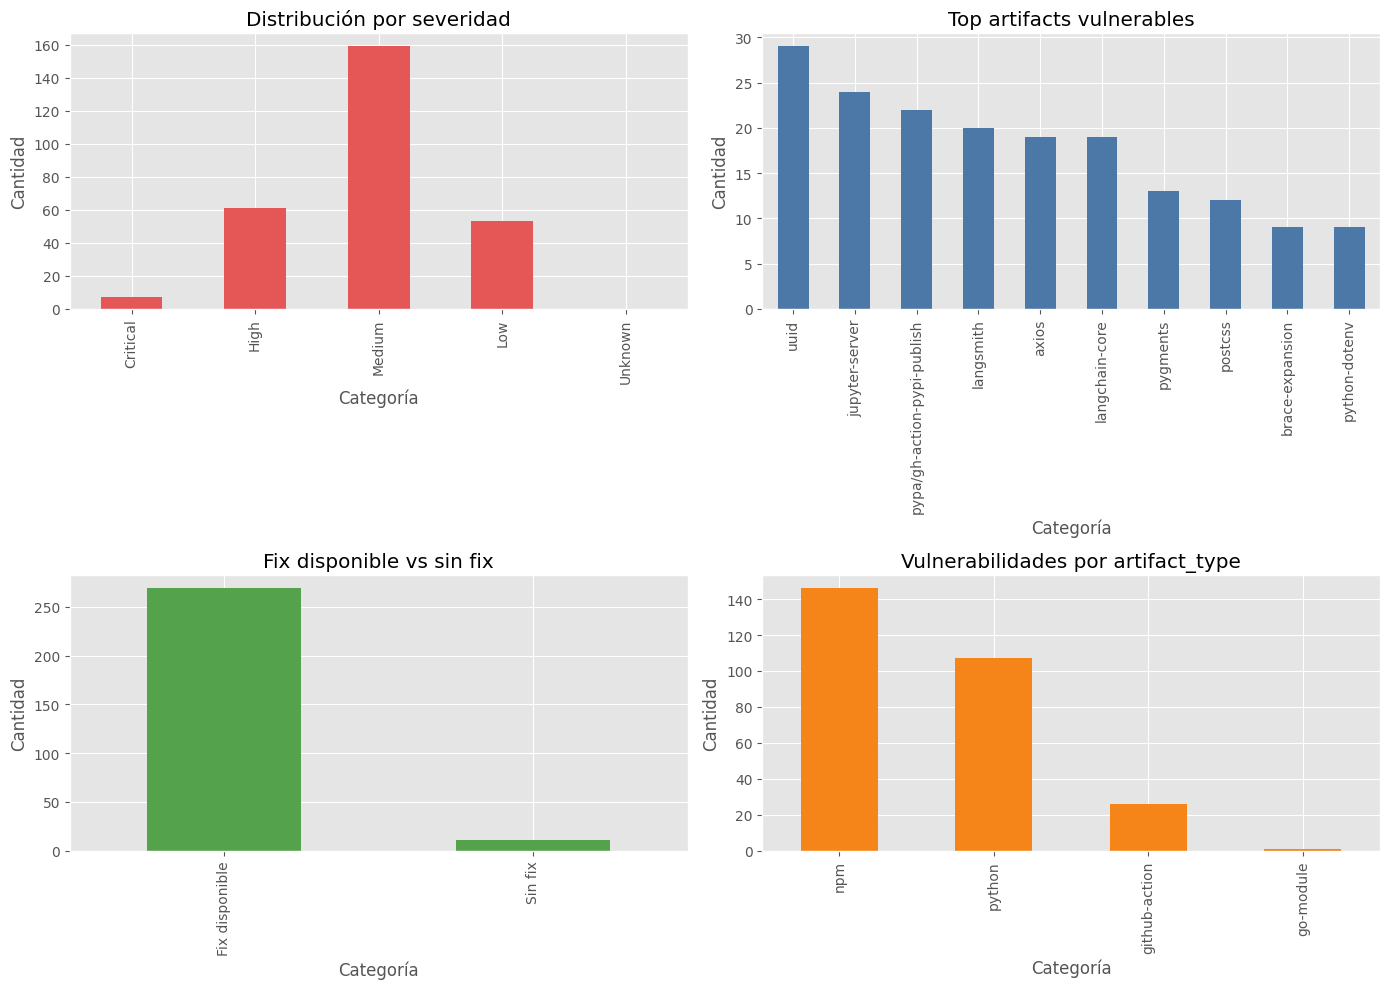

In [6]:
plt.style.use('ggplot')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

severity_counts.plot(kind='bar', ax=axes[0, 0], color='#E45756', title='Distribución por severidad')
top_artifacts.plot(kind='bar', ax=axes[0, 1], color='#4C78A8', title='Top artifacts vulnerables')
fix_counts.plot(kind='bar', ax=axes[1, 0], color='#54A24B', title='Fix disponible vs sin fix')
by_type.plot(kind='bar', ax=axes[1, 1], color='#F58518', title='Vulnerabilidades por artifact_type')

for ax in axes.ravel():
    ax.set_xlabel('Categoría')
    ax.set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

,repo,components,vulnerabilities
0,agent-auth-payments,1068,5
1,agent-chat-ui,778,1
2,agent-inbox,630,4
3,agents-from-scratch-ts,270,22
4,chat-langchain,0,0
5,deep-agent-template-js,454,7
6,deepagents,2262,10
7,deepagentsjs,737,3
8,docs,551,5
9,fleet-deepagent-export,187,0


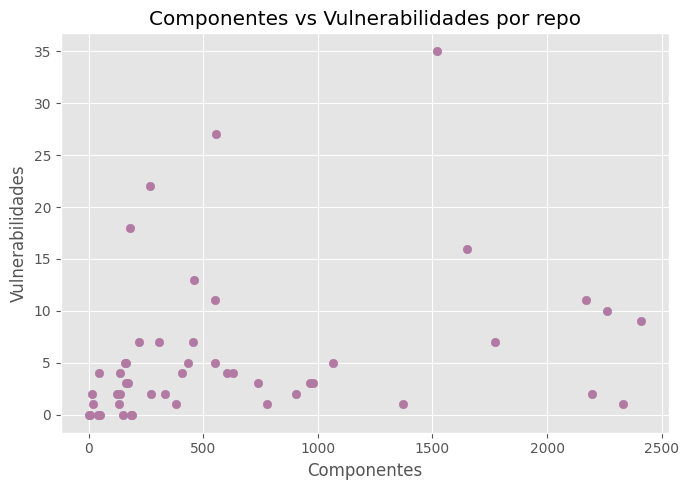

Pearson (components vs vulnerabilities): 0.2717


In [7]:
# Correlación componentes vs vulnerabilidades

df_repo_corr = df_repo.copy()
display(df_repo_corr)

plt.figure(figsize=(7, 5))
if not df_repo_corr.empty:
    plt.scatter(df_repo_corr['components'], df_repo_corr['vulnerabilities'], color='#B279A2')
    plt.xlabel('Componentes')
    plt.ylabel('Vulnerabilidades')
    plt.title('Componentes vs Vulnerabilidades por repo')
else:
    plt.text(0.5, 0.5, 'Sin datos', ha='center', va='center')
plt.tight_layout()
plt.show()

valid_pairs = df_repo_corr[['components', 'vulnerabilities']].dropna()
if len(valid_pairs) >= 2 and valid_pairs['components'].nunique() > 1 and valid_pairs['vulnerabilities'].nunique() > 1:
    corr = valid_pairs['components'].corr(valid_pairs['vulnerabilities'], method='pearson')
    print(f'Pearson (components vs vulnerabilities): {corr:.4f}')
else:
    print('Pearson no calculable con datos actuales (muestras insuficientes o sin variación).')

In [8]:
# CWEs transversales: en cuántos repos aparece cada CWE
if df_vulns.empty:
    cwe_cross = pd.DataFrame(columns=['cwe', 'repo_count'])
else:
    cwe_cross = (
        df_vulns[df_vulns['cwe'] != 'Unknown']
        .groupby('cwe')['repo']
        .nunique()
        .sort_values(ascending=False)
        .reset_index(name='repo_count')
    )

display(cwe_cross.head(20))

repeated_cwe = cwe_cross[cwe_cross['repo_count'] > 1]
print(f"CWEs presentes en más de un repo: {len(repeated_cwe)}")

,cwe,repo_count
0,CWE-787,17
1,CWE-400,14
2,CWE-79,11
3,CWE-200,9
4,CWE-22,9
5,CWE-1321,8
6,CWE-918,7
7,CWE-601,6
8,CWE-613,6
9,CWE-777,6


CWEs presentes en más de un repo: 21


,count
rule_id,
py/clear-text-logging-sensitive-data,68
py/incomplete-url-substring-sanitization,48
js/file-system-race,27
js/insecure-temporary-file,20
js/incomplete-url-substring-sanitization,14
js/prototype-polluting-assignment,9
js/polynomial-redos,8
js/biased-cryptographic-random,6
js/weak-cryptographic-algorithm,6


,count
level,
warning,165
error,84


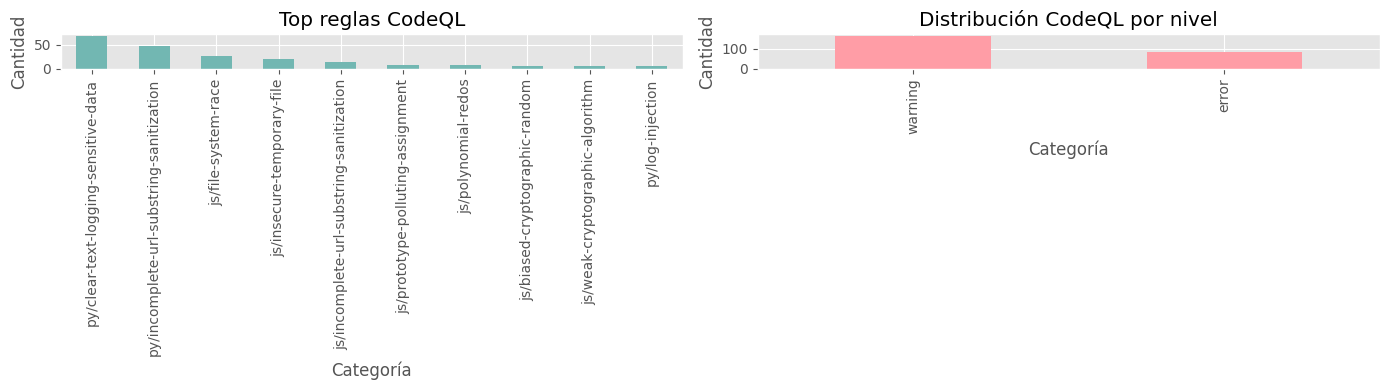

In [9]:
# Reglas CodeQL comunes y distribución por nivel
rule_counts = df_codeql['rule_id'].value_counts().head(10)
level_counts = df_codeql['level'].value_counts()

display(rule_counts.to_frame('count'))
display(level_counts.to_frame('count'))

if not rule_counts.empty or not level_counts.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    rule_counts.plot(kind='bar', ax=axes[0], color='#72B7B2', title='Top reglas CodeQL')
    level_counts.plot(kind='bar', ax=axes[1], color='#FF9DA6', title='Distribución CodeQL por nivel')
    for ax in axes:
        ax.set_xlabel('Categoría')
        ax.set_ylabel('Cantidad')
    plt.tight_layout()
    plt.show()
else:
    print('No hay issues de CodeQL para mostrar reglas/niveles.')

## Interpretación de patrones

### Severidad
Revisar severidad permite separar ruido de riesgo material. Un aumento de niveles **High/Critical** sugiere necesidad de mitigación prioritaria.

### Artifacts vulnerables
Los artifacts más afectados ayudan a localizar superficies de ataque repetidas (dependencias, librerías o imágenes base).

### CWE
**CWE** describe el tipo de debilidad (no una vulnerabilidad específica). Si un CWE aparece en varios repositorios, puede requerir controles transversales (guías, linters, hardening de plantillas).

### `fix_available`
Cuando `fix_available` es verdadero, existe ruta de remediación más directa (upgrade/patch). Esto impacta la priorización porque reduce tiempo de exposición.

### Correlación componentes vs vulnerabilidades
Una correlación positiva sugiere que repos con más componentes tienden a exponer más hallazgos. No implica causalidad, pero sí apoya decisiones de higiene de dependencias.

### Reglas CodeQL frecuentes
Reglas repetidas indican patrones de codificación inseguros o controles faltantes en revisión de código.

### Patrones en múltiples repositorios
Si un patrón aparece en más de un repo, el riesgo deja de ser local y pasa a ser organizacional.

## Conclusión parcial
Este notebook muestra qué tipos de vulnerabilidades se repiten, qué componentes concentran más riesgo y qué hallazgos podrían priorizarse por severidad, frecuencia o disponibilidad de fix.
El EDA sobre datos raw añade capas de análisis (CVSS, EPSS, fix gap) que no están disponibles en el consolidado.
